# Hierarchical lab 1

In [1]:
import numpy as np
import pandas as pd
from scipy import ndimage
from scipy.cluster import hierarchy
from scipy.spatial import distance_matrix
import matplotlib.pyplot as plt
from sklearn import manifold, datasets
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs

In [2]:
X1, y1 = make_blobs(n_samples=50, centers=[[4,4],[-2,-1],[1,1],[10,4]], cluster_std=0.9)

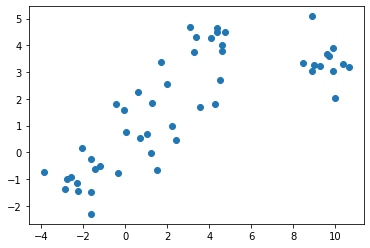

In [5]:
plt.scatter(X1[:, 0], X1[:, 1], marker='o')

In [6]:
agglom = AgglomerativeClustering(n_clusters=4, linkage='average')

In [7]:
agglom.fit(X1, y1)

AgglomerativeClustering(linkage='average', n_clusters=4)

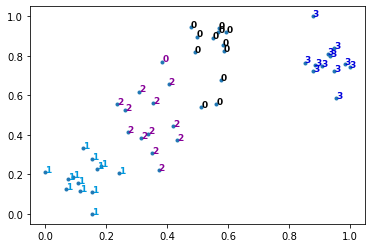

In [13]:
plt.figure(figsize=(6,4))

x_min, x_max = np.min(X1, axis=0), np.max(X1, axis=0)

X1 = (X1 - x_min) / (x_max - x_min)

for i in range(X1.shape[0]):
    plt.text(X1[i, 0], X1[i, 1], str(y1[i]),
    color=plt.cm.nipy_spectral(agglom.labels_[i]/ 10.),
    fontdict={'weight': 'bold', 'size': 9})
    
plt.xticks()
plt.yticks()

plt.scatter(X1[:, 0], X1[:, 1], marker='.')

plt.show()

In [14]:
dist_matrix = distance_matrix(X1, X1)
print(dist_matrix)

[[0.         0.98028328 0.64941967 ... 0.97547495 0.82208088 0.55198425]
 [0.98028328 0.         0.43502297 ... 0.07064089 0.15863893 0.50709543]
 [0.64941967 0.43502297 0.         ... 0.39621479 0.31885921 0.09786695]
 ...
 [0.97547495 0.07064089 0.39621479 ... 0.         0.17130601 0.47661327]
 [0.82208088 0.15863893 0.31885921 ... 0.17130601 0.         0.37302574]
 [0.55198425 0.50709543 0.09786695 ... 0.47661327 0.37302574 0.        ]]


In [17]:
Z = hierarchy.linkage(dist_matrix, 'average')

/tmp/ipykernel_62051/2305343628.py:1: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = hierarchy.linkage(dist_matrix, 'average')


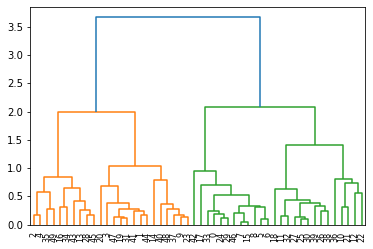

In [18]:
dendrogram = hierarchy.dendrogram(Z)

# Practice

In [28]:
X2, y2 = make_blobs(n_samples=50, centers=[[4,4],[-2,-1],[1,1],[10,4]], cluster_std=0.9)

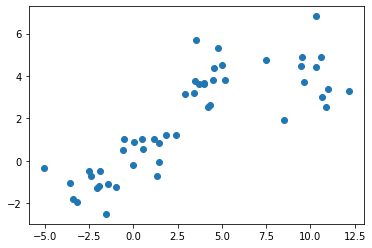

In [29]:
plt.scatter(X2[:, 0], X2[:, 1], marker='o')

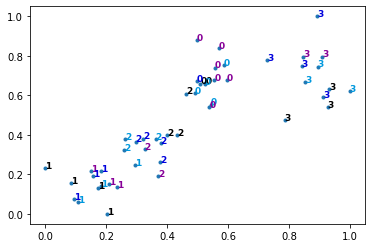

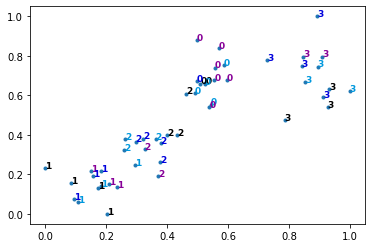

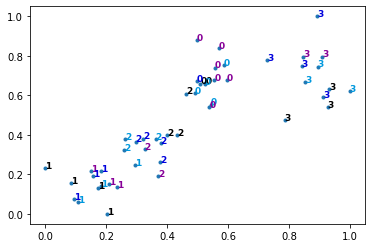

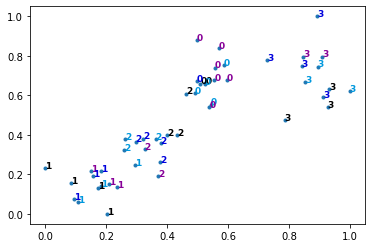

In [30]:
for link in ['ward', 'average', 'complete', 'single']:
    agglom_best = AgglomerativeClustering(n_clusters=3, linkage=link)
    agglom_best.fit(X2, y2)
    plt.figure(figsize=(6,4))

    x_min, x_max = np.min(X2, axis=0), np.max(X2, axis=0)

    X2 = (X2 - x_min) / (x_max - x_min)

    for i in range(X2.shape[0]):
        plt.text(X2[i, 0], X2[i, 1], str(y2[i]),
        color=plt.cm.nipy_spectral(agglom.labels_[i]/ 10.),
        fontdict={'weight': 'bold', 'size': 9})

    plt.xticks()
    plt.yticks()

    plt.scatter(X2[:, 0], X2[:, 1], marker='.')

    plt.show()